**PARTE PREVIA**

A continuación realizaremos un estudio sobre los 6 datasets subidos para realizar el trabajo práctico (en adelante TP). Esto será compartido con todo el equipo.

Empezaremos por un análisis previo con el claro objetivo de ver que datasets elegimos para realizar el TP.

**INFORMACIÓN SOBRE LOS DATOS**

*  C. elegans: Una red dirigida y pesada que representa la red de conexiones neuronales en el organismo Caenorhabditis elegans (un nematodo). Cada nodo es una neurona, y cada enlace una conexión entre neuronas. El sistema nervioso de este organismo es el único al cual se le han podido reconstruir todas sus conexiones neuronales. Además, en este dataset también se indica si la conexión sináptica es excitatoria (’exc’) o inhibitoria  (’inh’), así como el peso de la conexión. Contiene 299 nodos y 2279 enlances.

*  Facebook: Una red no dirigida y no pesada de círculos de Facebook. Los datos fueron regoidos por una encuesta realizada en la app de Facebook. Cada nodo es un perfil de Facebook y un enlace significa que los perfiles son amigos en Facebook. Contiene 4039 nodos y 88234 enlaces.

*  Email-EU: Una red no dirigida y no pesada de contactos vía e-mail en una institución europea de investigación. Cada nodo es una persona dentro de la institución, un enlace significa que estas personas intercambiaron al menos un email. Para este dataset también tenemos un label conocido de antemano para cada nodo, que representa a qué departamento de la institución pertenece el nodo. Contiene 1005 nodos y 25571 enlaces.

*  Aeropuertos: Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos, y los enlaces representan vuelos realizados en el año 2025. El peso de cada enlace indica el número total de vuelos de dicha ruta. Hay información sobre las coordenadas espaciales de cada aeropuerto. Contiene 1252 nodos y 23092 enlaces.

*  CONICET: Una red no dirigida y no pesada. Cada nodo es un autor de un subconjunto de la base de datos del CONICET para las publicaciones entre 2023 y 2024.
Tiene metadatos de los autores con sus áreas de investigación. Tiene 8288 nodos y 14105 enlaces.

*  Bariloche: Una red dirigida y pesada construida a partir de la información disponible en OpenStreetMap (vía el paquete osmnx). Cada nodo es una intersección y cada enlace una vía manejable. Contiene metadatos adicionales con la ubicación, tipo de vía y velocidad máxima, entre otros. Tiene 4905 nodos y 13582 enlaces.

**SET DE INDICADORES PARA REALIZAR EL ANÁLISIS E INSPECCIÓN DE LOS DATASETS PREVIA ELECCIÓN**

*  Características de las redes: es dirigído?, es pesado? es conectado? es fuertemente conexo? es debilmente conexo?
*  Análisis de componente gigante: borrando autoenlaces, analizamos su conexión
*  Realizamos una visualización espacial de cada nodo si existe información sobre posición.
*  Grados de nodo
*  Coeficiente de clustering
*  Coeficiente de transitividad
*  Coeficiente de asortatividad
*  Distancias mínimas medias

In [65]:
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl

import pandas as pd
import pickle

In [1]:
# DATOS REDES:
!wget -O datasets-tp1.zip https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7&st=09rgvayp&dl=1
!unzip -o datasets-tp1.zip

"wget" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"st" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"dl" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"unzip" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [2]:
import pandas as pd
import networkx as nx

# Cargar datos
df_edges = pd.read_csv("datasets/celegans_connectome.csv")

# Crear grafo dirigido
G = nx.DiGraph()

# Agregar aristas con atributos
for _, row in df_edges.iterrows():
    G.add_edge(
        row["Neuron"],
        row["Target"],
        weight=row["weight"],
        synapse_type=row["Neurotransmitter"]
    )


In [3]:
df_edges.head()

,Unnamed: 0,Neuron,Target,weight,Neurotransmitter
0,0,ADAL,AIBL,1.0,exc
1,1,ADAL,AIBR,2.0,exc
2,2,ADAL,AVAR,2.0,exc
3,3,ADAL,AVBL,4.0,exc
4,4,ADAL,AVBR,7.0,exc


In [4]:
df_pos = pd.read_csv("datasets/celegans_positions.csv")

print(df_pos.head())

  Unnamed: 0       0         1         2
0       ADAL   8.650 -322.6291 -1.089988
1       ADAR -12.900 -322.6291 -1.089988
2       ADEL  11.000 -326.0401 -0.886702
3       ADER -15.300 -326.0401 -0.886702
4       ADFL   3.725 -353.0995  1.670831


In [7]:
import pandas as pd
import networkx as nx

df_edges = pd.read_csv("datasets/celegans_connectome.csv")

G = nx.from_pandas_edgelist(
    df_edges,
    source="Neuron",
    target="Target",
    edge_attr=["weight", "Neurotransmitter"],  # 🔥 CLAVE
    create_using=nx.DiGraph()
)


In [8]:
pos = {
    row["Unnamed: 0"]: (row["0"], row["1"])
    for _, row in df_pos.iterrows()
}

In [9]:
def diagnostico_grafo(G, nombre):
    print(f"--- Diagnóstico: {nombre} ---")
    print(G)

    dirigido = nx.is_directed(G)
    print(f'¿Es dirigido?: {dirigido}')

    es_pesado = any('weight' in data for _, _, data in G.edges(data=True))
    print(f'¿Es pesado?: {es_pesado}')

    tiene_tipo = any('Neurotransmitter' in data for _, _, data in G.edges(data=True))
    print(f'¿Tiene tipo de sinapsis?: {tiene_tipo}')

    if dirigido:
        print(f'¿Es conexo (débil)?: {nx.is_weakly_connected(G)}')
        print(f'¿Es conexo (fuerte)?: {nx.is_strongly_connected(G)}')
    else:
        print(f'¿Es conectado?: {nx.is_connected(G)}')

    print("\n")


diagnostico_grafo(G, "Red neuronal")

--- Diagnóstico: Red neuronal ---
DiGraph with 299 nodes and 2279 edges
¿Es dirigido?: True
¿Es pesado?: True
¿Tiene tipo de sinapsis?: True
¿Es conexo (débil)?: False
¿Es conexo (fuerte)?: False




El análisis de la red neuronal del organismo Caenorhabditis elegans permitió caracterizar su estructura como un grafo dirigido y pesado, en el cual las conexiones sinápticas presentan tanto dirección como intensidad, además de una diferenciación funcional entre sinapsis excitatorias e inhibitorias. Estas propiedades reflejan de manera fiel la complejidad biológica del sistema nervioso estudiado.

A partir del diagnóstico estructural, se observó que la red no es conexa ni en sentido débil ni fuerte, lo que indica la presencia de múltiples componentes y una organización no homogénea. Este resultado sugiere una marcada modularidad, donde grupos de neuronas se organizan en subredes funcionales relativamente independientes.

Asimismo, la ausencia de conectividad fuerte global y la existencia de componentes fuertemente conexas de menor tamaño evidencian la presencia de circuitos locales, los cuales podrían corresponder a bucles de retroalimentación relevantes para el procesamiento de información neuronal.

Por otro lado, la naturaleza dirigida del grafo pone de manifiesto un flujo de información estructurado y no recíproco, consistente con la transmisión sináptica en sistemas biológicos reales. En conjunto, estos hallazgos indican que la red neuronal analizada presenta una organización eficiente y especializada, caracterizada por la coexistencia de integración local y direccionalidad global en la propagación de señales.”

In [10]:
exc = sum(1 for _,_,d in G.edges(data=True) if d['Neurotransmitter'] == 'exc')
inh = sum(1 for _,_,d in G.edges(data=True) if d['Neurotransmitter'] == 'inh')

print("Excitatorias:", exc)
print("Inhibitorias:", inh)

Excitatorias: 2079
Inhibitorias: 200


In [12]:
strength_out = dict(G.out_degree(weight='weight'))
print (strength_out) # qué neuronas “envían” más señal

{'ADAL': 32.0, 'AIBL': 39.0, 'AIBR': 35.0, 'AVAR': 153.0, 'AVBL': 34.0, 'AVBR': 26.0, 'AVDL': 53.0, 'AVEL': 58.0, 'AVJR': 22.0, 'FLPR': 49.0, 'RICL': 28.0, 'RICR': 22.0, 'RIML': 22.0, 'RIPL': 2.0, 'SMDVR': 16.0, 'ADAR': 23.0, 'AVAL': 143.0, 'AVJL': 20.0, 'RIMR': 36.0, 'RIPR': 2.0, 'RIVR': 15.0, 'SMDVL': 18.0, 'ADEL': 37.0, 'ADER': 37.0, 'AVL': 25.0, 'BDUL': 12.0, 'CEPDL': 46.0, 'FLPL': 68.0, 'IL1L': 19.0, 'IL2L': 35.0, 'OLLL': 62.0, 'RIAL': 96.0, 'RIFL': 23.0, 'RIGL': 15.0, 'RIGR': 14.0, 'RIH': 69.0, 'RIVL': 10.0, 'RMDL': 15.0, 'RMGL': 26.0, 'RMHL': 1.0, 'SIADR': 0, 'SIBDR': 0, 'SMBDR': 8.0, 'URBL': 9.0, 'ALA': 6.0, 'AVDR': 60.0, 'AVER': 54.0, 'AVKL': 18.0, 'AVKR': 13.0, 'CEPDR': 50.0, 'OLLR': 63.0, 'PVR': 35.0, 'RMDR': 16.0, 'SAAVR': 26.0, 'ADFL': 39.0, 'AIZL': 50.0, 'AUAL': 21.0, 'OLQVL': 12.0, 'RIR': 29.0, 'SMBVL': 9.0, 'ADFR': 43.0, 'AIYR': 19.0, 'AIZR': 36.0, 'ASHR': 40.0, 'AUAR': 26.0, 'AWBR': 17.0, 'PVPR': 42.0, 'RIAR': 99.0, 'SMBVR': 7.0, 'URXR': 21.0, 'ADLL': 41.0, 'AIAL': 26.

In [13]:
nx.betweenness_centrality(G) #detecta neuronas puente

{'ADAL': 0.005022017766563705,
 'AIBL': 0.027950089042969112,
 'AIBR': 0.013906876195486546,
 'AVAR': 0.11198423999213315,
 'AVBL': 0.02355037868149809,
 'AVBR': 0.01824455633396095,
 'AVDL': 0.012352345774660269,
 'AVEL': 0.020339054019058198,
 'AVJR': 0.005540804172103848,
 'FLPR': 0.0005867435147814999,
 'RICL': 0.011053413813187,
 'RICR': 0.014360511434790568,
 'RIML': 0.007239301104390981,
 'RIPL': 0.003914814532553918,
 'SMDVR': 0.001327595080590638,
 'ADAR': 0.005950833408129173,
 'AVAL': 0.10103397348376207,
 'AVJL': 0.01650575564584948,
 'RIMR': 0.017917372533251735,
 'RIPR': 0.004730613419829518,
 'RIVR': 0.0022094430851044284,
 'SMDVL': 0.006602778510570696,
 'ADEL': 0.011338978223958214,
 'ADER': 0.029942137435936152,
 'AVL': 0.010408340132161617,
 'BDUL': 0.0058471012382818495,
 'CEPDL': 0.005787670836249362,
 'FLPL': 0.006131503100505698,
 'IL1L': 0.0009582157896583985,
 'IL2L': 0.00174368265812297,
 'OLLL': 0.0032974866625099216,
 'RIAL': 0.021894800693235753,
 'RIFL': 0

In [ ]:
largest_cc = max(nx.weakly_connected_components(G), key=len)
print(len(largest_cc)) #El tamaño de la componente débilmente conectada más grande
#Cuántas neuronas pertenecen al sistema conectado principal del cerebro de C. elegans

279


In [15]:
# componente débilmente conectada
largest_wcc = max(nx.weakly_connected_components(G), key=len)

# componente fuertemente conectada
largest_scc = max(nx.strongly_connected_components(G), key=len)

print("Weakly connected:", len(largest_wcc))
print("Strongly connected:", len(largest_scc))

Weakly connected: 279
Strongly connected: 237


In [16]:
print("Número de WCC:", nx.number_weakly_connected_components(G))
print("Número de SCC:", nx.number_strongly_connected_components(G))

Número de WCC: 2
Número de SCC: 53


“La red presenta únicamente dos componentes débilmente conectadas (La red se divide en 2 grupos de neuronas que no están conectados entre sí, ni siquiera ignorando la dirección), lo que indica que la gran mayoría de las neuronas forman parte de un sistema globalmente integrado. Sin embargo, la presencia de 53 componentes fuertemente conectadas evidencia una organización altamente modular en términos dirigidos, donde la mayoría de las neuronas no forman parte de ciclos bidireccionales, sino que participan en circuitos locales o en flujos unidireccionales de información.”

In [ ]:
sizes_wcc = sorted([len(c) for c in nx.weakly_connected_components(G)], reverse=True)
print(sizes_wcc) #Tenés 2 componentes débilmente conectadas:
#Una grande: 279 neuronas
#Una pequeña: 20 neuronas
# 👉 Total = 299 (todo cierra)

[279, 20]


In [20]:
print(df_edges.columns)

Index(['Unnamed: 0', 'Neuron', 'Target', 'weight', 'Neurotransmitter'], dtype='str')


In [22]:
print(df_edges['Neurotransmitter'].unique())

<StringArray>
['exc', 'inh']
Length: 2, dtype: str


🔹 1. Separar redes

In [24]:
G_exc = nx.from_pandas_edgelist(
    df_edges[df_edges['Neurotransmitter'] == 'exc'],
    source='Neuron',
    target='Target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

G_inh = nx.from_pandas_edgelist(
    df_edges[df_edges['Neurotransmitter'] == 'inh'],
    source='Neuron',
    target='Target',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

🔹 2. Ver proporciones globales

In [25]:
print(df_edges['Neurotransmitter'].value_counts())

Neurotransmitter
exc    2079
inh     200
Name: count, dtype: int64


🔹 3. Analizar TU subred de 20 neuronas

In [ ]:
small_cc = [c for c in nx.weakly_connected_components(G) if len(c) == 20][0]

df_small = df_edges[
    df_edges['Neuron'].isin(small_cc) &
    df_edges['Target'].isin(small_cc)
]

print(df_small['Neurotransmitter'].value_counts()) 
#👉 En tu subred de 20 neuronas: 100% de las conexiones son excitatorias 0 conexiones inhibitorias

Neurotransmitter
exc    85
Name: count, dtype: int64


“La subred aislada de 20 neuronas está compuesta exclusivamente por conexiones excitatorias, lo que sugiere un circuito especializado en la propagación de señales sin mecanismos internos de inhibición. Esta característica, junto con su desconexión del resto de la red, indica que podría tratarse de un módulo funcional independiente, potencialmente dedicado a una respuesta específica o a un procesamiento local sin regulación inhibitoria interna.”

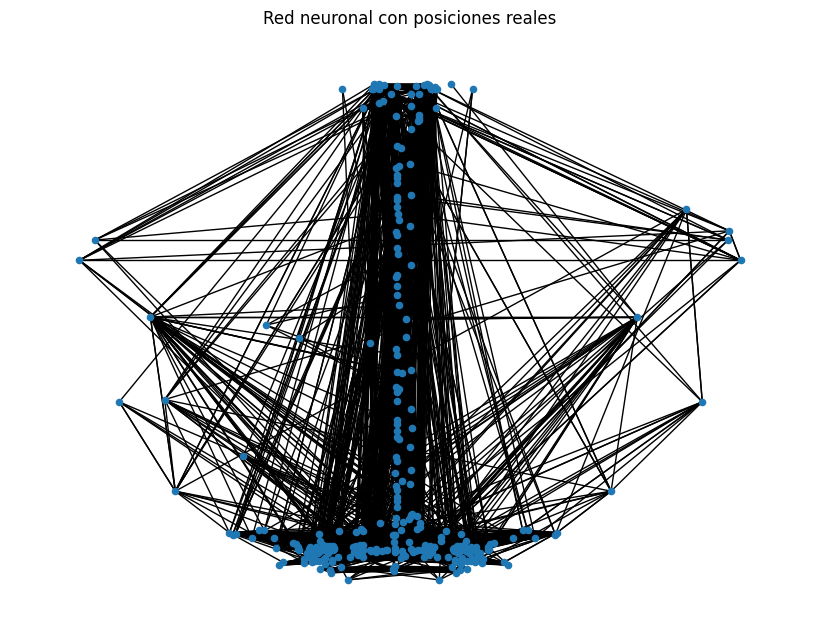

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_size=20,
    arrows=False
)

plt.title("Red neuronal con posiciones reales")
plt.show()


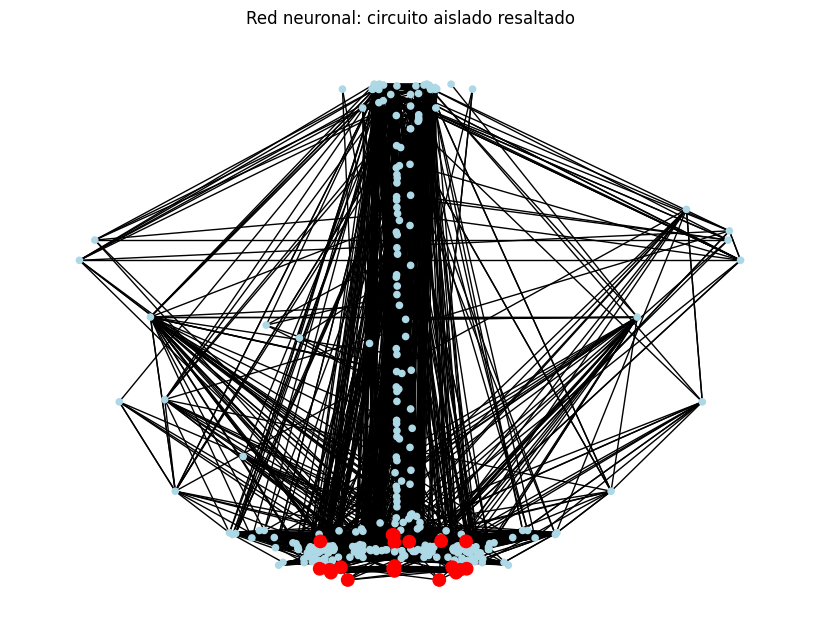

In [31]:
small_cc = [c for c in nx.weakly_connected_components(G) if len(c) == 20][0]

node_colors = []
node_sizes = []

for n in G.nodes():
    if n in small_cc:
        node_colors.append('red')
        node_sizes.append(80)
    else:
        node_colors.append('lightblue')
        node_sizes.append(20)

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,   # ⚠️ asegurate que exista
    node_size=node_sizes,
    node_color=node_colors,
    arrows=False
)

plt.title("Red neuronal: circuito aislado resaltado")
plt.show()

In [33]:
edge_colors = []

for u, v in G.edges():
    # buscar tipo en el dataframe original
    tipo = df_edges[
        (df_edges['Neuron'] == u) & (df_edges['Target'] == v)
    ]['Neurotransmitter'].values

    if len(tipo) > 0:
        if tipo[0] == 'exc':
            edge_colors.append('green')
        else:
            edge_colors.append('red')
    else:
        edge_colors.append('gray')  # por si falta info


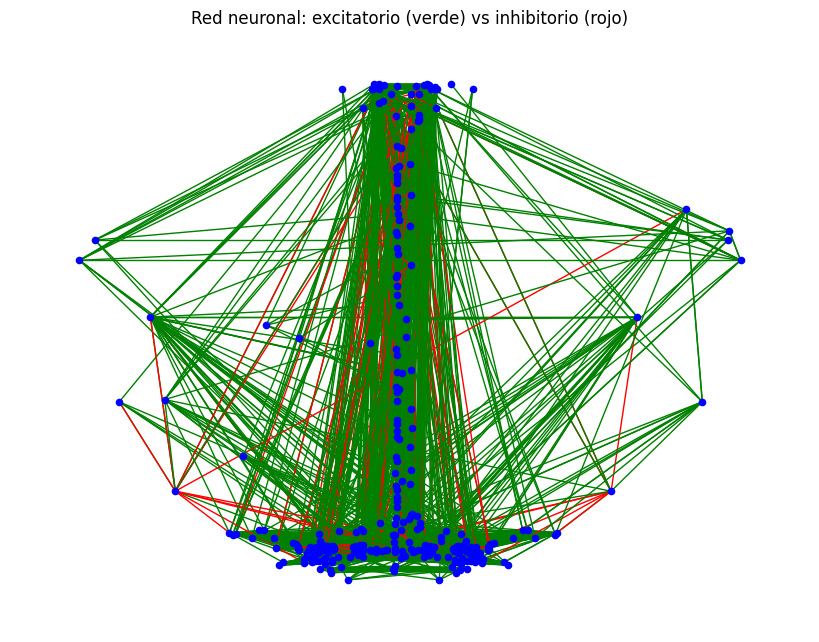

In [38]:
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_size=20,
    node_color='blue',
    edge_color=edge_colors,
    arrows=False
)

plt.title("Red neuronal: excitatorio (verde) vs inhibitorio (rojo)")
plt.show()

**PARA EL GRAFO COMPLETO**

In [39]:
import networkx as nx
import numpy as np

# =========================
# INFO GENERAL
# =========================
print("=== GRAFO DIRIGIDO ===")
print("Nodos:", G.number_of_nodes())
print("Aristas:", G.number_of_edges())

# =========================
# GRADO PROMEDIO (total)
# =========================
degrees = [d for n, d in G.degree()]
avg_degree = np.mean(degrees)

print("Grado promedio (total):", avg_degree)

# =========================
# GRADO ENTRADA / SALIDA
# =========================
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

print("Grado de entrada promedio:", np.mean(in_degrees))
print("Grado de salida promedio:", np.mean(out_degrees))

# =========================
# CLUSTERING (requiere no dirigido)
# =========================
G_und = G.to_undirected()

clustering = nx.average_clustering(G_und)
print("Clustering (sobre versión no dirigida):", clustering)

# =========================
# TRANSITIVIDAD
# =========================
transitivity = nx.transitivity(G_und)
print("Transitividad:", transitivity)

# =========================
# ASORTATIVIDAD (grado total)
# =========================
assortativity = nx.degree_assortativity_coefficient(G_und)
print("Asortatividad:", assortativity)

# =========================
# COMPONENTE GIGANTE (para distancias)
# =========================
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_gc = G.subgraph(largest_cc).to_undirected().copy()

# =========================
# DISTANCIA MEDIA
# =========================
avg_path = nx.average_shortest_path_length(G_gc)
print("Distancia mínima media:", avg_path)

=== GRAFO DIRIGIDO ===
Nodos: 299
Aristas: 2279
Grado promedio (total): 15.244147157190636
Grado de entrada promedio: 7.622073578595318
Grado de salida promedio: 7.622073578595318
Clustering (sobre versión no dirigida): 0.32858984556092147
Transitividad: 0.20162821011228246
Asortatividad: -0.06699901934800966
Distancia mínima media: 2.569531471596916


El análisis de la red neuronal de Caenorhabditis elegans muestra que se trata de un grafo dirigido y pesado, con predominio de conexiones excitatorias (2079 frente a 200 inhibitorias), lo que sugiere una red orientada principalmente a la propagación de señales con mecanismos de regulación inhibitoria.

A nivel estructural, aunque la red no es completamente conexa, presenta una componente gigante que abarca el 93% de los nodos, evidenciando una alta integración global. Además, el bajo valor de asortatividad (negativa) indica una tendencia a que nodos muy conectados se vinculen con nodos menos conectados, característica típica de redes biológicas.

Por otro lado, el coeficiente de clustering relativamente alto y la corta distancia media (≈2.57) sugieren una organización tipo small-world, que favorece tanto la especialización local como la eficiencia en la transmisión de información. Finalmente, el análisis de centralidad permite identificar nodos clave con roles fundamentales en la integración y el flujo de señales dentro de la red.

**PARA EL GRAFO CON SOLO LA COMPONENTE PRINCIPAL**

In [40]:
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_gc = G.subgraph(largest_cc).copy()

In [85]:
print("=== COMPONENTE GIGANTE ===")
print("Nodos:", G_gc.number_of_nodes())
print("Aristas:", G_gc.number_of_edges())

print("Grado promedio:", sum(dict(G_gc.degree()).values()) / G_gc.number_of_nodes())

print("Clustering:", nx.average_clustering(G_gc.to_undirected()))
print("Transitividad:", nx.transitivity(G_gc.to_undirected()))
print("Asortatividad:", nx.degree_assortativity_coefficient(G_gc))

print("Distancia media:", nx.average_shortest_path_length(G_gc.to_undirected()))

=== COMPONENTE GIGANTE ===
Nodos: 279
Aristas: 2194
Grado promedio: 15.727598566308243
Clustering: 0.3203026999598745
Transitividad: 0.19873904779565157
Asortatividad: -0.041488068960509064
Distancia media: 2.569531471596916


El análisis de la red neuronal de Caenorhabditis elegans muestra que se trata de un grafo dirigido y pesado, con predominio de conexiones excitatorias (2079 frente a 200 inhibitorias), lo que sugiere una red orientada principalmente a la propagación de señales con regulación inhibitoria.

Al comparar las métricas calculadas sobre la red completa y sobre su componente gigante (279 nodos, ≈93% del total), se observa que los valores son muy similares, en particular la distancia media (2.57) y el clustering (0.32). Esto indica que la estructura global de la red está dominada por su componente principal, mientras que los nodos restantes tienen un impacto limitado en las propiedades topológicas generales.

Asimismo, el leve aumento en el grado promedio dentro de la componente gigante sugiere que los nodos excluidos corresponden a regiones menos conectadas de la red. Por otro lado, la asortatividad negativa en ambos casos refleja una organización en la que nodos altamente conectados tienden a vincularse con nodos de menor grado, característica típica de redes biológicas.

En conjunto, estos resultados evidencian que la red presenta una organización eficiente tipo small-world, donde la mayor parte de la estructura funcional se concentra en la componente gigante, permitiendo una integración global eficiente junto con especialización local.

In [41]:
import networkx as nx

# =========================
# CENTRALIDADES
# =========================

# 1. Centralidad de grado
grado = nx.degree_centrality(G_gc)
in_grado = nx.in_degree_centrality(G_gc)
out_grado = nx.out_degree_centrality(G_gc)

# 2. Centralidad de intermediación
betweenness = nx.betweenness_centrality(G_gc)

# 3. Centralidad de autovector
try:
    eigen = nx.eigenvector_centrality(G_gc, max_iter=1000)
except:
    eigen = nx.eigenvector_centrality(G_gc.to_undirected(), max_iter=1000)

# =========================
# FUNCIÓN PARA TOP NODOS
# =========================

def top_n(dic, n=5):
    return sorted(dic.items(), key=lambda x: x[1], reverse=True)[:n]

# =========================
# RESULTADOS
# =========================

print("=== TOP NODOS ===\n")

print("Top grado total:")
print(top_n(grado), "\n")

print("Top grado de entrada:")
print(top_n(in_grado), "\n")

print("Top grado de salida:")
print(top_n(out_grado), "\n")

print("Top betweenness:")
print(top_n(betweenness), "\n")

print("Top eigenvector:")
print(top_n(eigen), "\n")

# =========================
# ANALISIS EXC/INH EN NODOS TOP
# =========================

print("=== TIPO DE SINAPSIS EN NODOS MÁS IMPORTANTES ===\n")

for nodo, _ in top_n(grado):
    vecinos = G_gc.out_edges(nodo, data=True)
    tipos = [d['Neurotransmitter'] for _, _, d in vecinos]

    exc = tipos.count('exc')
    inh = tipos.count('inh')

    print(f"{nodo} -> Exc: {exc}, Inh: {inh}")


=== TOP NODOS ===

Top grado total:
[('AVAR', 0.3525179856115108), ('AVAL', 0.32374100719424465), ('AVBL', 0.21582733812949642), ('PVCL', 0.21223021582733814), ('PVCR', 0.20863309352517986)] 

Top grado de entrada:
[('AVAL', 0.1906474820143885), ('AVAR', 0.1762589928057554), ('AVBL', 0.14388489208633093), ('AVBR', 0.1366906474820144), ('AVEL', 0.12949640287769784)] 

Top grado de salida:
[('AVAR', 0.1762589928057554), ('AVAL', 0.13309352517985612), ('DVA', 0.12589928057553956), ('PVCL', 0.11510791366906475), ('PVCR', 0.11510791366906475)] 

Top betweenness:
[('AVAR', 0.12870785581310207), ('AVAL', 0.11612228731727199), ('PVCR', 0.05866607071629648), ('PVT', 0.04737784904212929), ('PVCL', 0.04691554293443539)] 

Top eigenvector:
[('AVAL', 0.27581538339980843), ('AVAR', 0.2687331767873964), ('AVDL', 0.18586794749372912), ('AVBL', 0.18018242909051138), ('DA3', 0.16175530214906986)] 

=== TIPO DE SINAPSIS EN NODOS MÁS IMPORTANTES ===

AVAR -> Exc: 49, Inh: 0
AVAL -> Exc: 37, Inh: 0
AVBL ->

El análisis de centralidad en la red neuronal de Caenorhabditis elegans permitió identificar un conjunto de neuronas clave con roles destacados en la estructura y dinámica del conectoma. En particular, nodos como AVAL y AVAR aparecen consistentemente entre los más importantes en todas las métricas (grado, intermediación y autovector), lo que indica que actúan simultáneamente como hubs altamente conectados, nodos puente en la transmisión de información y elementos influyentes a nivel global.

Asimismo, neuronas como PVCL, PVCR, AVBL y PVT presentan altos valores de intermediación, sugiriendo que cumplen un rol relevante en la conexión entre distintas regiones de la red y en el control del flujo de información. Por otro lado, la centralidad de autovector destaca nodos como AVDL y DA3, indicando su importancia dentro de subredes altamente conectadas.

Un aspecto destacable es que las neuronas con mayor grado de salida presentan exclusivamente conexiones excitatorias, lo que refuerza la idea de que los nodos más influyentes de la red están principalmente involucrados en la propagación de señales, mientras que la inhibición tendría un rol más localizado y modulador.

En conjunto, estos resultados evidencian la presencia de una arquitectura jerárquica en la red, donde un conjunto reducido de neuronas clave concentra funciones de integración, transmisión y coordinación, contribuyendo a la eficiencia global del sistema nervios

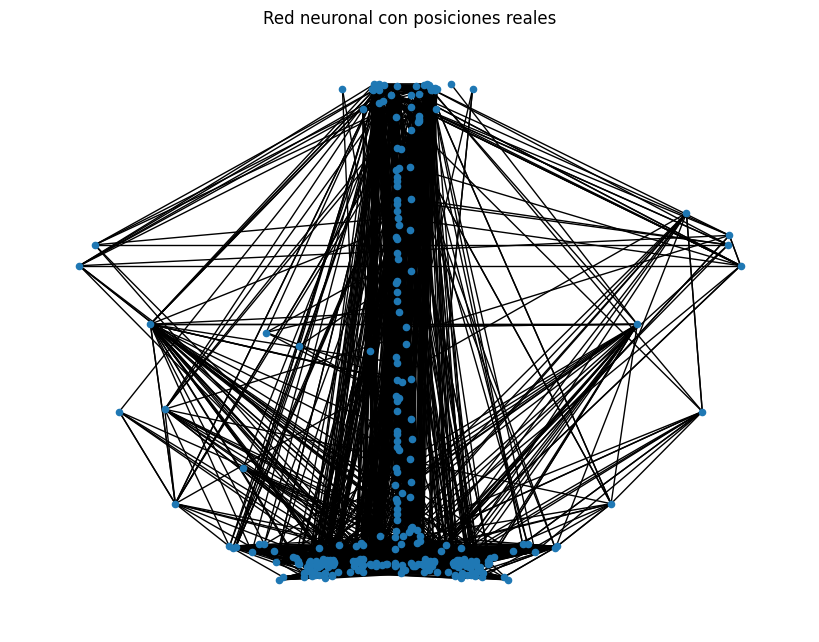

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

nx.draw(
    G_gc,
    pos,  # 🔥 posiciones reales
    node_size=20,
    arrows=False
)

plt.title("Red neuronal con posiciones reales")
plt.show()

Index(['Unnamed: 0', '0', '1', '2'], dtype='str')


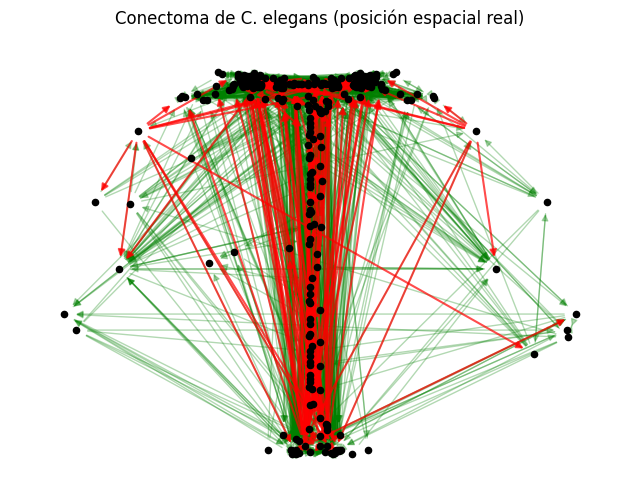

In [44]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Cargar posiciones
# =========================
df_pos = pd.read_csv("datasets/celegans_positions.csv")

# 🔍 Ajustar nombres si hace falta
# (asegurate que estas columnas existan)
print(df_pos.columns)

# =========================
# 2. Crear diccionario de posiciones
# =========================
pos_raw = {
    row["Unnamed: 0"]: (row["0"], row["1"])
    for _, row in df_pos.iterrows()
}

# =========================
# 3. NORMALIZAR posiciones (🔥 clave)
# =========================
xs = np.array([p[0] for p in pos_raw.values()])
ys = np.array([p[1] for p in pos_raw.values()])

xs = (xs - xs.min()) / (xs.max() - xs.min())
ys = (ys - ys.min()) / (ys.max() - ys.min())

pos_norm = {
    n: (x, y)
    for n, x, y in zip(pos_raw.keys(), xs, ys)
}

# 👉 opcional: invertir eje Y (muchas veces necesario)
pos_norm = {n: (x, 1 - y) for n, (x, y) in pos_norm.items()}

# =========================
# 4. Filtrar nodos presentes en el grafo
# =========================
pos_filtered = {n: pos_norm[n] for n in G_gc.nodes() if n in pos_norm}

# =========================
# 5. Separar aristas
# =========================
edges_exc = [
    (u, v) for u, v, d in G_gc.edges(data=True)
    if d['Neurotransmitter'] == 'exc' and u in pos_filtered and v in pos_filtered
]

edges_inh = [
    (u, v) for u, v, d in G_gc.edges(data=True)
    if d['Neurotransmitter'] == 'inh' and u in pos_filtered and v in pos_filtered
]

# =========================
# 6. Graficar
# =========================
plt.figure(figsize=(8,6))

# Nodos
nx.draw_networkx_nodes(
    G_gc,
    pos_filtered,
    node_size=20,
    node_color='black'
)

# Aristas excitatorias
nx.draw_networkx_edges(
    G_gc,
    pos_filtered,
    edgelist=edges_exc,
    edge_color='green',
    alpha=0.3
)

# Aristas inhibitorias (más visibles 🔥)
nx.draw_networkx_edges(
    G_gc,
    pos_filtered,
    edgelist=edges_inh,
    edge_color='red',
    width=1.5,
    alpha=0.7
)

plt.title("Conectoma de C. elegans (posición espacial real)")
plt.axis('off')
plt.show()

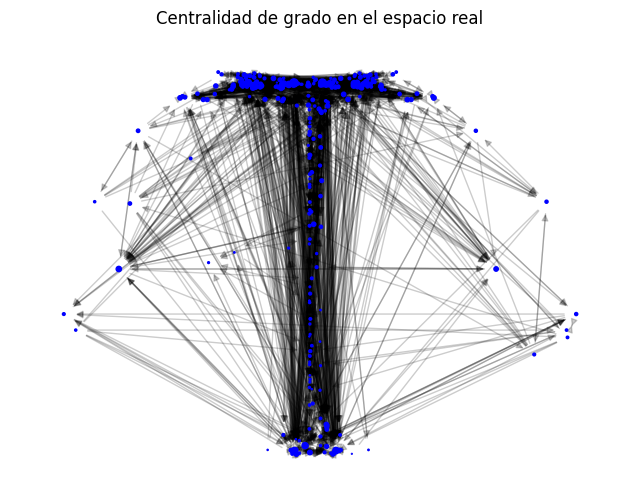

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# =========================
# 1. Filtrar nodos con posición
# =========================
pos_filtered = {n: pos_norm[n] for n in G_gc.nodes() if n in pos_norm}

# =========================
# 2. Tamaños según grado
# =========================
sizes = [100 * grado[n] for n in pos_filtered.keys()]

# =========================
# 3. Dibujar
# =========================
nx.draw_networkx_nodes(
    G_gc,
    pos_filtered,
    node_size=sizes,
    node_color='blue'
)

nx.draw_networkx_edges(
    G_gc,
    pos_filtered,
    alpha=0.2
)

plt.title("Centralidad de grado en el espacio real")
plt.axis('off')
plt.show()

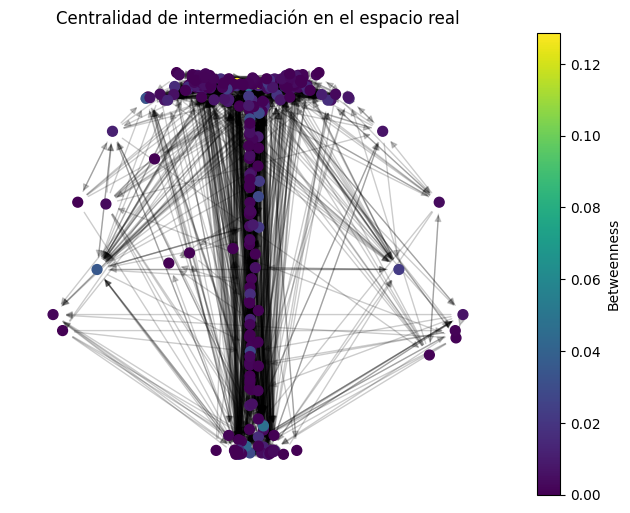

In [49]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(8,6))

# =========================
# 1. Filtrar nodos con posición
# =========================
pos_filtered = {n: pos_norm[n] for n in G_gc.nodes() if n in pos_norm}

# =========================
# 2. Valores de betweenness (solo nodos visibles)
# =========================
values = [betweenness[n] for n in pos_filtered.keys()]

# =========================
# 3. Dibujar nodos
# =========================
nodes = nx.draw_networkx_nodes(
    G_gc,
    pos_filtered,
    ax=ax,
    node_color=values,
    node_size=50,
    cmap=plt.cm.viridis
)

# =========================
# 4. Dibujar aristas
# =========================
nx.draw_networkx_edges(
    G_gc,
    pos_filtered,
    ax=ax,
    alpha=0.2
)

# =========================
# 5. Escala de color (🔥 correcta)
# =========================
sm = mpl.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(values), vmax=max(values))
)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Betweenness")

# =========================
# 6. Título y estilo
# =========================
plt.title("Centralidad de intermediación en el espacio real")
plt.axis('off')

plt.show()

In [97]:
pagerank = nx.pagerank(G_gc, alpha=0.85)

print("Top PageRank:")
print(top_n(pagerank))

Top PageRank:
[('RMDDR', 0.04294294581877805), ('RMDVL', 0.04085970547453632), ('DD1', 0.03253819688437405), ('VD2', 0.030640682072793902), ('RMDVR', 0.025964611387847673)]


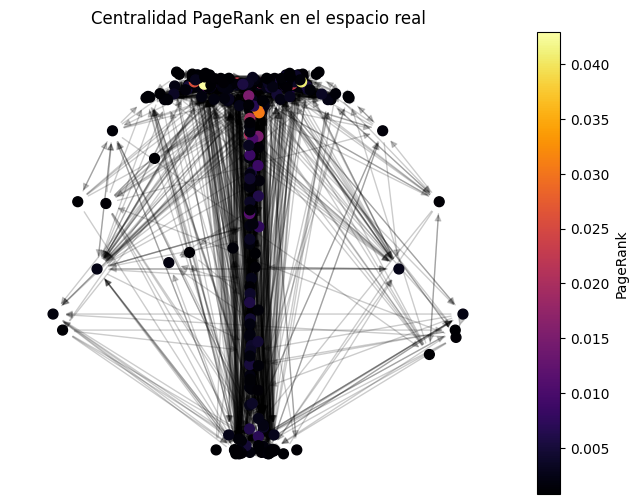

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(8,6))

# =========================
# 1. Filtrar nodos con posición real
# =========================
pos_filtered = {n: pos_norm[n] for n in G_gc.nodes() if n in pos_norm}

# =========================
# 2. Valores de PageRank (solo nodos visibles)
# =========================
pagerank = nx.pagerank(G_gc, weight='weight')
values = [pagerank[n] for n in pos_filtered.keys()]

# =========================
# 3. Nodos
# =========================
nx.draw_networkx_nodes(
    G_gc,
    pos_filtered,
    ax=ax,
    node_color=values,
    node_size=50,
    cmap=plt.cm.inferno
)

# =========================
# 4. Aristas
# =========================
nx.draw_networkx_edges(
    G_gc,
    pos_filtered,
    ax=ax,
    alpha=0.2
)

# =========================
# 5. Escala de color
# =========================
sm = mpl.cm.ScalarMappable(
    cmap=plt.cm.inferno,
    norm=plt.Normalize(vmin=min(values), vmax=max(values))
)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="PageRank")

# =========================
# 6. Estética final
# =========================
plt.title("Centralidad PageRank en el espacio real")
plt.axis('off')

plt.show()

El análisis de centralidad en la red neuronal de Caenorhabditis elegans permitió identificar distintos tipos de nodos clave según la métrica utilizada. Mientras que las centralidades de grado, intermediación y autovector destacan neuronas como AVAL y AVAR, asociadas a roles de integración global y transmisión de información, la centralidad PageRank identifica un conjunto diferente de nodos, como RMDDR, RMDVL, DD1 y VD2, que se caracterizan por recibir conexiones desde neuronas relevantes.

Esta diferencia sugiere la existencia de una organización funcional jerárquica, donde algunos nodos actúan como centros de distribución y otros como receptores estratégicos dentro del flujo de información. En conjunto, el uso de múltiples métricas de centralidad permite una caracterización más completa del conectoma, evidenciando la diversidad de roles que cumplen las neuronas dentro de la red.

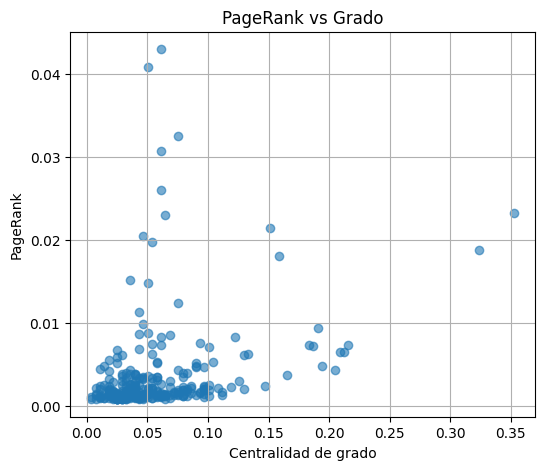

In [52]:
import matplotlib.pyplot as plt

# Datos
grado_vals = [grado[n] for n in G_gc.nodes()]
pagerank_vals = [pagerank[n] for n in G_gc.nodes()]

plt.figure(figsize=(6,5))

plt.scatter(grado_vals, pagerank_vals, alpha=0.6)

plt.xlabel("Centralidad de grado")
plt.ylabel("PageRank")
plt.title("PageRank vs Grado")

plt.grid(True)
plt.show()

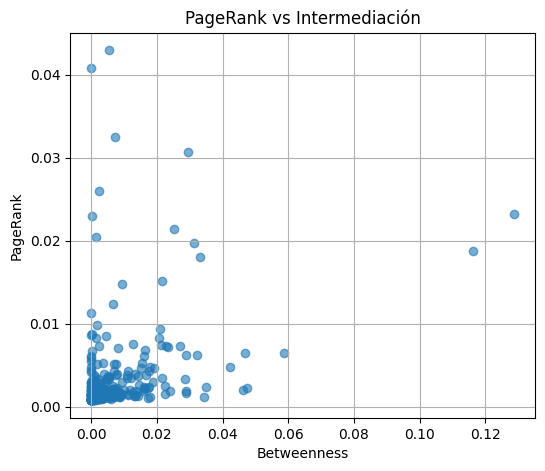

In [53]:
# Datos
bet_vals = [betweenness[n] for n in G_gc.nodes()]
pagerank_vals = [pagerank[n] for n in G_gc.nodes()]

plt.figure(figsize=(6,5))

plt.scatter(bet_vals, pagerank_vals, alpha=0.6)

plt.xlabel("Betweenness")
plt.ylabel("PageRank")
plt.title("PageRank vs Intermediación")

plt.grid(True)
plt.show()

Ahora voy a evaluar robustez, en particular la sigyuiente hipotesis: “La red de aeropuertos será más vulnerable a la remoción de nodos con alta centralidad de intermediación que a la remoción de nodos al azar.”

Vamos a comparar:
1.   eliminación aleatoria
2.   eliminación por PageRank
3.  eliminación por intermediación

Nodos en grafo: 279
Nodos en PR order: 279
Nodos en Bet order: 279


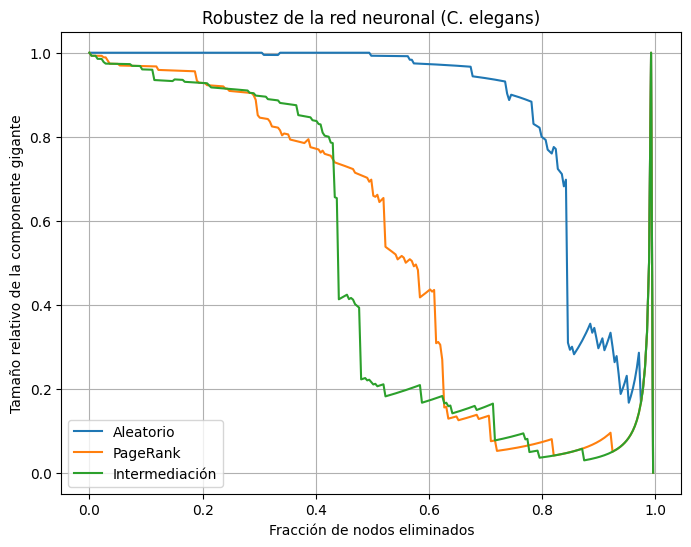

In [54]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# =========================
# 1. Usar componente gigante y pasar a no dirigido
# =========================
G_und = G_gc.to_undirected()

# =========================
# 2. Centralidades (SIN weight explícito)
# =========================
pagerank_full = nx.pagerank(G_und)
betweenness_full = nx.betweenness_centrality(G_und)

# =========================
# 3. Órdenes de eliminación
# =========================
nodes = list(G_und.nodes())

random_order = nodes.copy()
random.shuffle(random_order)

pr_order = sorted(pagerank_full, key=pagerank_full.get, reverse=True)
bet_order = sorted(betweenness_full, key=betweenness_full.get, reverse=True)

# Chequeo
print("Nodos en grafo:", len(nodes))
print("Nodos en PR order:", len(pr_order))
print("Nodos en Bet order:", len(bet_order))

# =========================
# 4. Función componente gigante
# =========================
def giant_component_fraction(G):
    if len(G) == 0:
        return 0
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / G.number_of_nodes()

# =========================
# 5. Copias del grafo
# =========================
G_rand = G_und.copy()
G_pr = G_und.copy()
G_bet = G_und.copy()

# =========================
# 6. Simulación
# =========================
frac_rand = []
frac_pr = []
frac_bet = []
steps = []

for i in range(len(nodes)):
    steps.append(i / len(nodes))

    # Aleatorio
    G_rand.remove_node(random_order[i])
    frac_rand.append(giant_component_fraction(G_rand))

    # PageRank
    G_pr.remove_node(pr_order[i])
    frac_pr.append(giant_component_fraction(G_pr))

    # Intermediación
    G_bet.remove_node(bet_order[i])
    frac_bet.append(giant_component_fraction(G_bet))

# =========================
# 7. Plot
# =========================
plt.figure(figsize=(8,6))

plt.plot(steps, frac_rand, label='Aleatorio')
plt.plot(steps, frac_pr, label='PageRank')
plt.plot(steps, frac_bet, label='Intermediación')

plt.xlabel("Fracción de nodos eliminados")
plt.ylabel("Tamaño relativo de la componente gigante")
plt.title("Robustez de la red neuronal (C. elegans)")

plt.legend()
plt.grid(True)
plt.show()

El análisis de robustez de la red neuronal de Caenorhabditis elegans muestra que el sistema es altamente robusto frente a eliminaciones aleatorias, manteniendo su conectividad incluso tras remover una gran fracción de nodos. Sin embargo, la red es mucho más vulnerable a ataques dirigidos, especialmente cuando se eliminan nodos con alta intermediación, lo que produce una rápida fragmentación de la componente gigante.

Esto indica que la conectividad global depende fuertemente de un conjunto reducido de nodos clave, que actúan como puentes en la red, evidenciando una organización eficiente pero estructuralmente sensible a fallas dirigidas.

COMPARACIÓN CON RED ALEATORIA

In [55]:
import networkx as nx

# =========================
# 1. Grafo original (usar componente gigante)
# =========================
G_und = G_gc.to_undirected()  # 🔥 usar componente gigante

N = G_und.number_of_nodes()
E = G_und.number_of_edges()

# Probabilidad Erdős–Rényi
p = (2 * E) / (N * (N - 1))

# =========================
# 2. Red aleatoria equivalente
# =========================
G_rand = nx.erdos_renyi_graph(N, p, seed=42)

# =========================
# 3. Función componente gigante
# =========================
def giant_component(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

G_rand_gc = giant_component(G_rand)

# =========================
# 4. Métricas
# =========================
def compute_metrics(G, G_gc):
    return {
        "clustering": nx.average_clustering(G),
        "transitivity": nx.transitivity(G),
        "assortativity": nx.degree_assortativity_coefficient(G),
        "path_length": nx.average_shortest_path_length(G_gc)
    }

metrics_real = compute_metrics(G_und, G_und)      # ya es componente gigante
metrics_rand = compute_metrics(G_rand, G_rand_gc)

# =========================
# 5. Resultados
# =========================
print("=== RED REAL ===")
for k, v in metrics_real.items():
    print(f"{k}: {v:.4f}")

print("\n=== RED ALEATORIA ===")
for k, v in metrics_rand.items():
    print(f"{k}: {v:.4f}")

=== RED REAL ===
clustering: 0.3203
transitivity: 0.1987
assortativity: -0.0912
path_length: 2.5695

=== RED ALEATORIA ===
clustering: 0.0435
transitivity: 0.0452
assortativity: 0.0335
path_length: 2.4346


La comparación entre la red neuronal de Caenorhabditis elegans y una red aleatoria equivalente revela diferencias estructurales claras. En particular, la red real presenta un coeficiente de clustering mucho mayor (0.32 vs 0.04), lo que indica una fuerte organización local y la presencia de grupos de neuronas altamente interconectadas.

En contraste, la distancia media es similar en ambas redes (~2.57 vs ~2.43), lo que sugiere que la eficiencia global en la transmisión de información se mantiene. Además, la asortatividad negativa en la red real refleja una organización distinta a la aleatoria.

En conjunto, estos resultados evidencian que la red neuronal no es aleatoria, sino que presenta una estructura tipo small-world, combinando alta cohesión local con caminos cortos entre nodos.

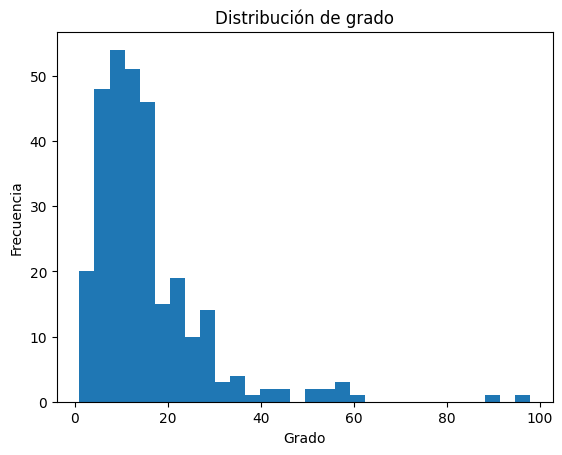

In [56]:
import matplotlib.pyplot as plt

degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=30)
plt.title("Distribución de grado")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.show()

“La distribución de grado presenta una cola larga hacia valores altos, indicando la presencia de unos pocos nodos altamente conectados en contraste con la mayoría de nodos de bajo grado. Esto sugiere una organización heterogénea de la red y la existencia de hubs, característica común en sistemas biológicos complejos.”

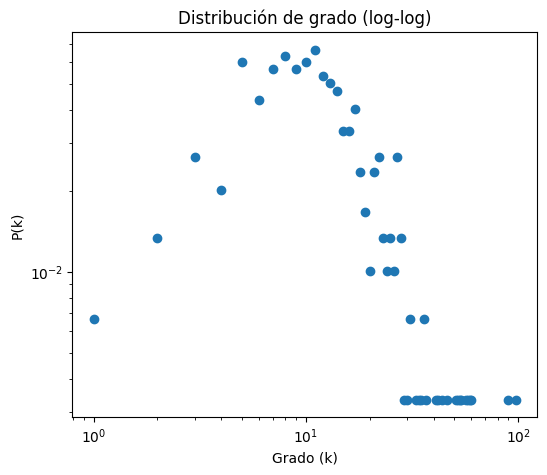

In [59]:
import numpy as np
import matplotlib.pyplot as plt

degrees = [d for n, d in G.degree()]

# contar frecuencia de cada grado
values, counts = np.unique(degrees, return_counts=True)

# normalizar (opcional pero mejor)
counts = counts / sum(counts)

plt.figure(figsize=(6,5))
plt.scatter(values, counts)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Grado (k)")
plt.ylabel("P(k)")
plt.title("Distribución de grado (log-log)")

plt.show()

“La distribución de grado en escala log-log no muestra una ley de potencia estricta, probablemente debido al tamaño limitado de la red. Sin embargo, se observa una cola hacia valores altos de grado, lo que indica la presencia de nodos altamente conectados (hubs) y una organización heterogénea de la red.”

In [60]:
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

for n, val in top_pr:
    print(n, val)

RMDDR 0.04294294581877805
RMDVL 0.04085970547453632
DD1 0.03253819688437405
VD2 0.030640682072793902
RMDVR 0.025964611387847673
AVAR 0.023222225424670017
RMDDL 0.022941022889564303
RIAL 0.02140671415598971
DA2 0.020408133915650835
VA2 0.019673369741525868


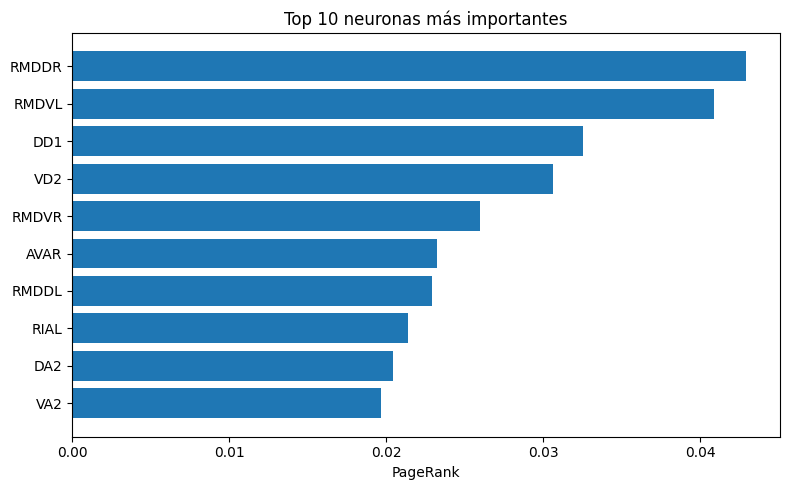

In [62]:
plt.figure(figsize=(8,5))
plt.barh(nodes[::-1], values[::-1])  # invertido para que el top quede arriba

plt.xlabel("PageRank")
plt.title("Top 10 neuronas más importantes")

plt.tight_layout()
plt.show()

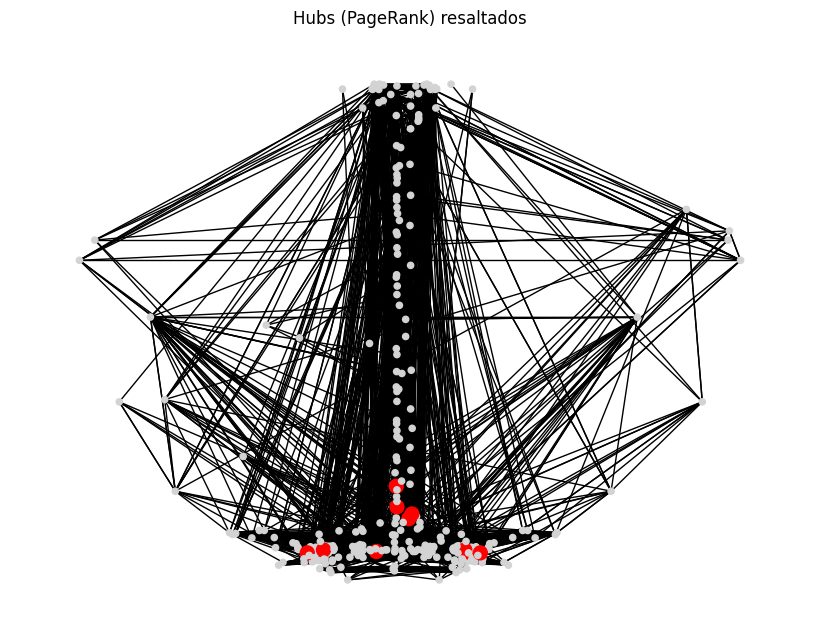

In [63]:
top_nodes = [n for n, _ in top_pr]

node_colors = [
    'red' if n in top_nodes else 'lightgray'
    for n in G.nodes()
]

node_sizes = [
    100 if n in top_nodes else 20
    for n in G.nodes()
]

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    arrows=False
)

plt.title("Hubs (PageRank) resaltados")
plt.show()

In [64]:
import community as community_louvain

# Louvain requiere grafo NO dirigido
G_und = G.to_undirected()

partition = community_louvain.best_partition(G_und)

In [66]:
pos_filtered = {n: pos_norm[n] for n in G.nodes() if n in pos_norm}

In [67]:
colors = [partition[n] for n in pos_filtered.keys()]

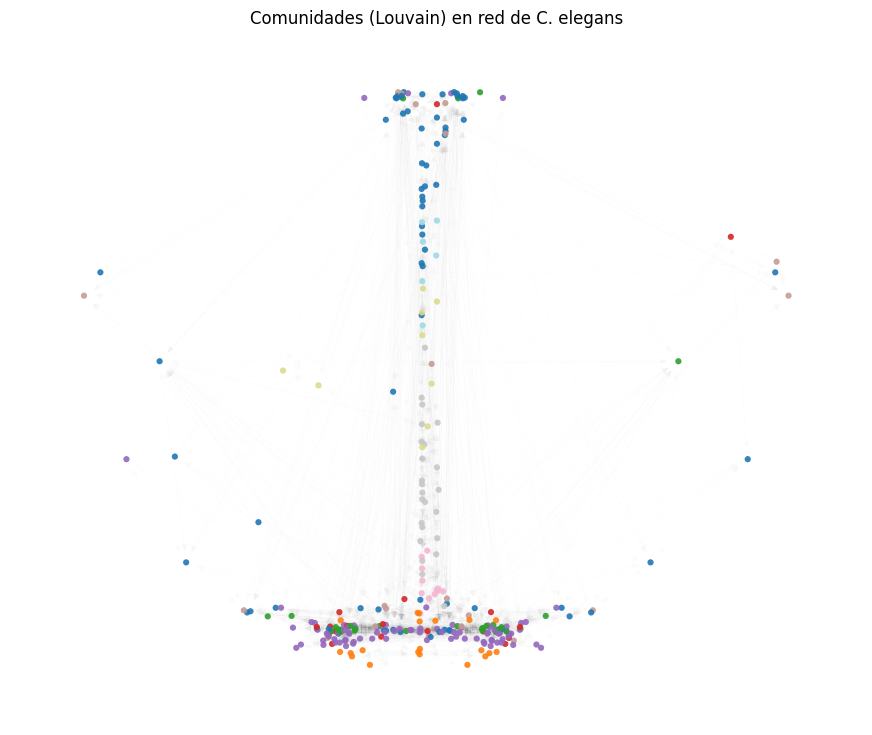

In [68]:
plt.figure(figsize=(11, 9))

# solo nodos con posición
nodes_plot = [n for n in G.nodes() if n in pos]

# colores según comunidad
colors = [partition[n] for n in nodes_plot]

# aristas
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.02,
    width=0.25,
    edge_color="gray"
)

# nodos
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodes_plot,
    node_size=20,
    node_color=colors,
    cmap=plt.cm.tab20,
    alpha=0.9,
    linewidths=0,
)

plt.title("Comunidades (Louvain) en red de C. elegans")
plt.axis("off")
plt.show()

In [69]:
# =========================
# Número de comunidades
# =========================
num_comunidades = len(set(partition.values()))
print("Número de comunidades:", num_comunidades)

# =========================
# Tamaño de cada comunidad
# =========================
from collections import Counter

conteo = Counter(partition.values())

# ordenar de mayor a menor
for comunidad, size in sorted(conteo.items(), key=lambda x: x[1], reverse=True):
    print(f"Comunidad {comunidad}: {size} nodos")

Número de comunidades: 10
Comunidad 4: 87 nodos
Comunidad 0: 71 nodos
Comunidad 2: 33 nodos
Comunidad 7: 24 nodos
Comunidad 5: 20 nodos
Comunidad 1: 20 nodos
Comunidad 3: 17 nodos
Comunidad 6: 12 nodos
Comunidad 8: 9 nodos
Comunidad 9: 6 nodos
